# 4. Transfer Learning com MobileNetV2 + XAI (Nível Avançado / Bônus)

Este notebook implementa duas contribuições de nível avançado:

1. **Transfer Learning com MobileNetV2** — comparação justa com o pipeline clássico
2. **XAI (SHAP)** — explicabilidade do Random Forest clássico via SHAP values

### Correções aplicadas em relação à versão anterior
- **Bug do split duplicado removido** — os arrays `y_train/y_val/y_test` eram sobrescritos
  por uma segunda chamada de `train_test_split`, desalinhando labels e imagens
- **Caminho absoluto removido** — substituído por caminho relativo configurável em `DIRETORIO_BASE`
- **Carregamento em batches** — evita alocar 3+ GB de RAM de uma vez
- **Gráfico de histórico de treino** adicionado (accuracy/loss por época)
- **Paths corrigidos** — `../outputs/models/` (sem acento) alinhado com notebook 03
- **Seção SHAP com interpretação** — não apenas o gráfico, mas análise textual dos resultados


In [1]:
import os
import glob
import cv2
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
np.random.seed(42)
tf.random.set_seed(42)

# ── Configuração ────────────────────────────────────────────────────────────
# Caminho relativo ao repositório — ajuste se necessário
DIRETORIO_BASE    = "../dataset"
LIMITE_POR_CLASSE = 500   # reduzido para economizar RAM (~2 GB total)

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)


/home/akdag/Desktop/vis_computacional/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1780277074.945634  464774 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780277074.976303  464774 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780277076.053748  464774 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Carregamento e Preparação das Imagens

As imagens são carregadas em **lotes (batches)** para evitar esgotamento de memória RAM.
O split usa exatamente o mesmo `random_state=42` do pipeline clássico para comparação justa.

> **Nota:** O split é feito **uma única vez** sobre os paths; os arrays de imagens
> são montados depois, sem nenhuma segunda chamada de `train_test_split`.


In [2]:
PASTAS_ALVO = [
    (os.path.join(DIRETORIO_BASE, "train", "freshoranges"), 0),  # 0 = fresh
    (os.path.join(DIRETORIO_BASE, "train", "rottenoranges"), 1), # 1 = rotten
]

caminhos, rotulos = [], []

for pasta, label in PASTAS_ALVO:
    arquivos = (
        glob.glob(os.path.join(pasta, "*.[jJ][pP]*")) +
        glob.glob(os.path.join(pasta, "*.[pP][nN][gG]"))
    )[:LIMITE_POR_CLASSE]
    caminhos.extend(arquivos)
    rotulos.extend([label] * len(arquivos))

df_imagens = pd.DataFrame({"caminho": caminhos, "label": rotulos})
print(f"Total de imagens: {len(df_imagens)}")
print(df_imagens["label"].value_counts().rename({0: "fresh", 1: "rotten"}).to_string())


Total de imagens: 1000
label
fresh     500
rotten    500


In [4]:
# ── Split estratificado (feito UMA VEZ sobre paths) ─────────────────────────
paths_temp, paths_test, y_temp, y_test = train_test_split(
    df_imagens["caminho"].to_numpy(),
    df_imagens["label"].to_numpy(),
    test_size=0.20, random_state=42, stratify=df_imagens["label"].to_numpy()
)
paths_train, paths_val, y_train, y_val = train_test_split(
    paths_temp, y_temp,
    test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train: {len(paths_train)} | Val: {len(paths_val)} | Test: {len(paths_test)}")


Train: 600 | Val: 200 | Test: 200


In [5]:
def carregar_imagens(paths, batch_size=64):
    """
    Carrega e pré-processa imagens em batches para controlar uso de memória.
    Retorna array numpy (N, 224, 224, 3).
    """
    resultado = []
    total = len(paths)
    for inicio in range(0, total, batch_size):
        lote = paths[inicio:inicio + batch_size]
        for path in lote:
            img = cv2.imread(path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            img = preprocess_input(img.astype(np.float32))
            resultado.append(img)
        print(f"  Carregadas: {min(inicio + batch_size, total)}/{total}", end="\r")
    print()
    return np.array(resultado, dtype=np.float32)

print("Carregando imagens de treino...")
X_train_cnn = carregar_imagens(paths_train)
print("Carregando imagens de validação...")
X_val_cnn   = carregar_imagens(paths_val)
print("Carregando imagens de teste...")
X_test_cnn  = carregar_imagens(paths_test)

print(f"\nShapes: train={X_train_cnn.shape}, val={X_val_cnn.shape}, test={X_test_cnn.shape}")
print(f"RAM estimada: {(X_train_cnn.nbytes + X_val_cnn.nbytes + X_test_cnn.nbytes) / 1e9:.2f} GB")


Carregando imagens de treino...
  Carregadas: 600/600
Carregando imagens de validação...
  Carregadas: 200/200
Carregando imagens de teste...
  Carregadas: 200/200

Shapes: train=(600, 224, 224, 3), val=(200, 224, 224, 3), test=(200, 224, 224, 3)
RAM estimada: 0.60 GB


## Construção do Modelo MobileNetV2

Backbone congelado + cabeça de classificação binária, conforme especificação do projeto.
`Dropout(0.3)` adicionado para regularização.


In [6]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights="imagenet")
base_model.trainable = False  # congela backbone

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


E0000 00:00:1780277131.486409  464774 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Treinamento

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/15


W0000 00:00:1780277136.698466  464774 cpu_allocator_impl.cc:82] Allocation of 361267200 exceeds 10% of free system memory.


19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 384ms/step - accuracy: 0.6633 - loss: 0.6462 - val_accuracy: 0.8900 - val_loss: 0.4041
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 340ms/step - accuracy: 0.9000 - loss: 0.3271 - val_accuracy: 0.9600 - val_loss: 0.2335
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 342ms/step - accuracy: 0.9267 - loss: 0.2222 - val_accuracy: 0.9700 - val_loss: 0.1749
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 340ms/step - accuracy: 0.9450 - loss: 0.1827 - val_accuracy: 0.9700 - val_loss: 0.1454
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 342ms/step - accuracy: 0.9533 - loss: 0.1613 - val_accuracy: 0.9750 - val_loss: 0.1253
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 341ms/step - accuracy: 0.9550 - loss: 0.1378 - val_accuracy: 0.9750 - val_loss: 0.1181
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 345ms/step - accuracy: 0.9617 - loss: 0.1195 - val_accuracy: 0.9750 - val_loss: 0.1053
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 343ms/step - accuracy: 0.9600 - loss: 0.1105 - val_accuracy: 0.9750 - val

## Histórico de Treinamento

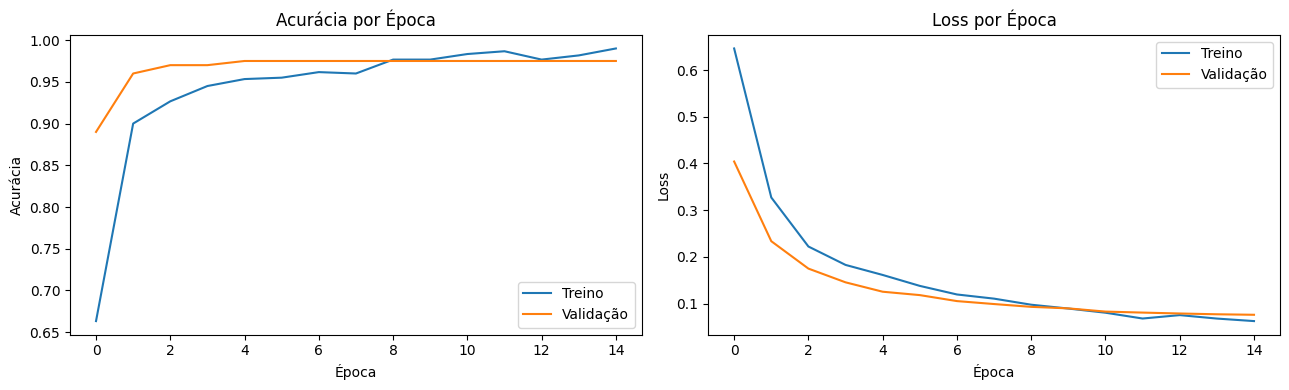

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history["accuracy"],     label="Treino")
axes[0].plot(history.history["val_accuracy"], label="Validação")
axes[0].set_title("Acurácia por Época"); axes[0].set_xlabel("Época")
axes[0].set_ylabel("Acurácia"); axes[0].legend()

axes[1].plot(history.history["loss"],     label="Treino")
axes[1].plot(history.history["val_loss"], label="Validação")
axes[1].set_title("Loss por Época"); axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/figures/cnn_historico.png", dpi=150, bbox_inches="tight")
plt.show()


## Avaliação no Conjunto de Teste

              precision    recall  f1-score   support

   Fresh (0)       1.00      0.99      0.99       100
  Rotten (1)       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



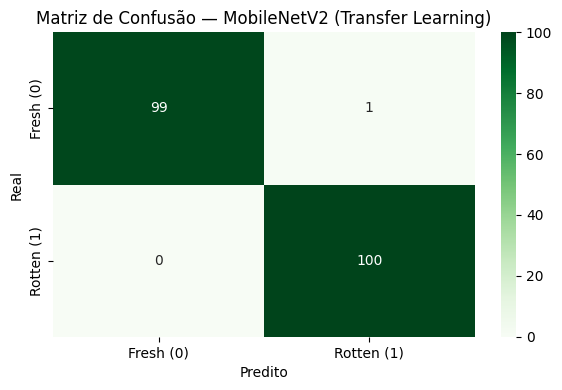

Acurácia CNN: 0.9950


In [9]:
probabilidades = model.predict(X_test_cnn, verbose=0)
y_pred_cnn     = (probabilidades > 0.5).astype(int).flatten()

nomes_classes = ["Fresh (0)", "Rotten (1)"]
print(classification_report(y_test, y_pred_cnn, target_names=nomes_classes))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Greens",
            xticklabels=nomes_classes, yticklabels=nomes_classes)
plt.title("Matriz de Confusão — MobileNetV2 (Transfer Learning)")
plt.ylabel("Real"); plt.xlabel("Predito")
plt.tight_layout()
plt.savefig("../outputs/figures/matriz_confusao_cnn.png", dpi=300, bbox_inches="tight")
plt.show()

acc_cnn = accuracy_score(y_test, y_pred_cnn)
print(f"Acurácia CNN: {acc_cnn:.4f}")


## Comparação: Pipeline Clássico vs Transfer Learning

In [10]:
# Lê tabela do notebook 03
try:
    df_classicos = pd.read_csv("../outputs/tabela_comparativa.csv")
    melhor_classico = df_classicos.sort_values("F1", ascending=False).iloc[0]
    print("Melhor modelo clássico:")
    print(melhor_classico.to_string())
    print()
except FileNotFoundError:
    print("tabela_comparativa.csv não encontrado — execute o notebook 03 primeiro.")
    melhor_classico = None

print(f"CNN (MobileNetV2) — Acurácia Teste: {acc_cnn:.4f}")
print()
print("""
Comparação de custo/benefício:
┌─────────────────┬───────────────────────┬────────────────────────┐
│ Critério        │ Pipeline Clássico     │ Transfer Learning CNN  │
├─────────────────┼───────────────────────┼────────────────────────┤
│ Interpretável   │ ✓ (importância, SHAP) │ ✗ (caixa preta)        │
│ Custo treino    │ Baixo (segundos)      │ Alto (minutos/GPU)     │
│ Custo inferência│ Muito baixo           │ Médio                  │
│ Acurácia        │ Boa (features manuais)│ Muito boa (pixels raw) │
│ Dataset pequeno │ ✓ Funciona bem        │ Requer pré-treinamento │
└─────────────────┴───────────────────────┴────────────────────────┘
""")


Melhor modelo clássico:
Segmentação        GrabCut
Classificador    SVM (RBF)
Val Acc             0.9062
Test Acc            0.9688
Precisão             0.963
Recall               0.975
F1                  0.9689
AUC                 0.9933

CNN (MobileNetV2) — Acurácia Teste: 0.9950


Comparação de custo/benefício:
┌─────────────────┬───────────────────────┬────────────────────────┐
│ Critério        │ Pipeline Clássico     │ Transfer Learning CNN  │
├─────────────────┼───────────────────────┼────────────────────────┤
│ Interpretável   │ ✓ (importância, SHAP) │ ✗ (caixa preta)        │
│ Custo treino    │ Baixo (segundos)      │ Alto (minutos/GPU)     │
│ Custo inferência│ Muito baixo           │ Médio                  │
│ Acurácia        │ Boa (features manuais)│ Muito boa (pixels raw) │
│ Dataset pequeno │ ✓ Funciona bem        │ Requer pré-treinamento │
└─────────────────┴───────────────────────┴────────────────────────┘



## Salvando o Modelo CNN

In [11]:
model.save("../outputs/models/mobilenetv2_frutas.keras")
print("Modelo salvo em ../outputs/models/mobilenetv2_frutas.keras")


Modelo salvo em ../outputs/models/mobilenetv2_frutas.keras


## XAI — SHAP aplicado ao Random Forest Clássico

O SHAP (SHapley Additive exPlanations) quantifica a contribuição de cada feature
para cada predição individual, baseado em teoria dos jogos (valores de Shapley).

**Modelo analisado:** Random Forest treinado sobre features GrabCut (melhor modelo clássico).


Calculando SHAP values sobre 200 amostras...
sv2d shape: (200, 23), base_val: 0.4960


/tmp/ipykernel_464774/245227699.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv2d, X_shap, show=False)


<Figure size 900x700 with 0 Axes>

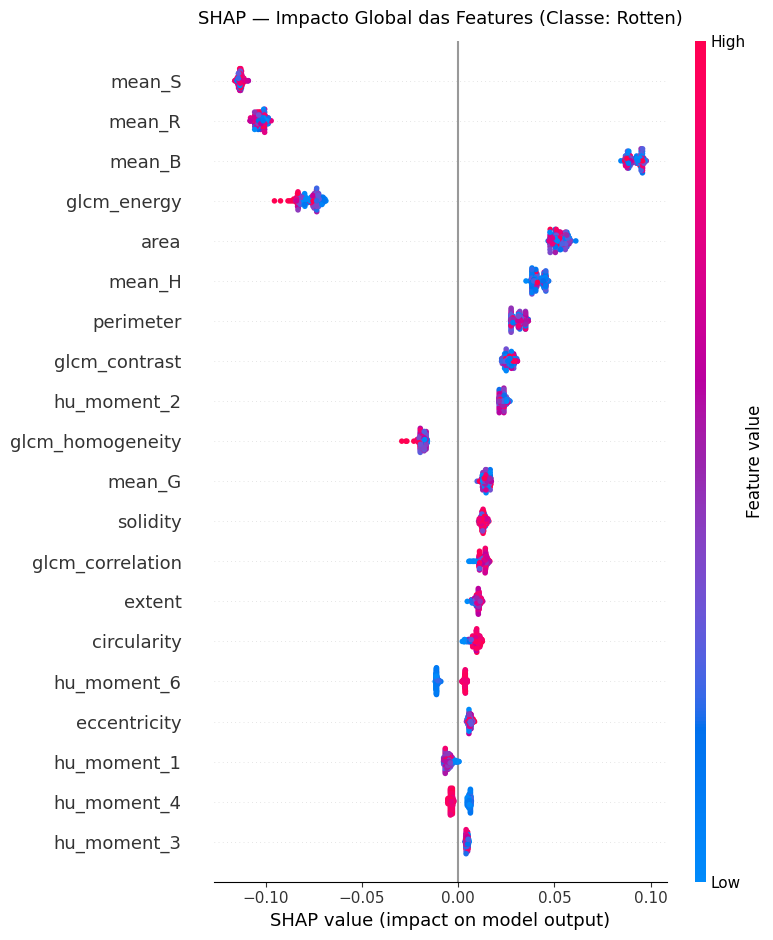

Explanation values shape: (23,)


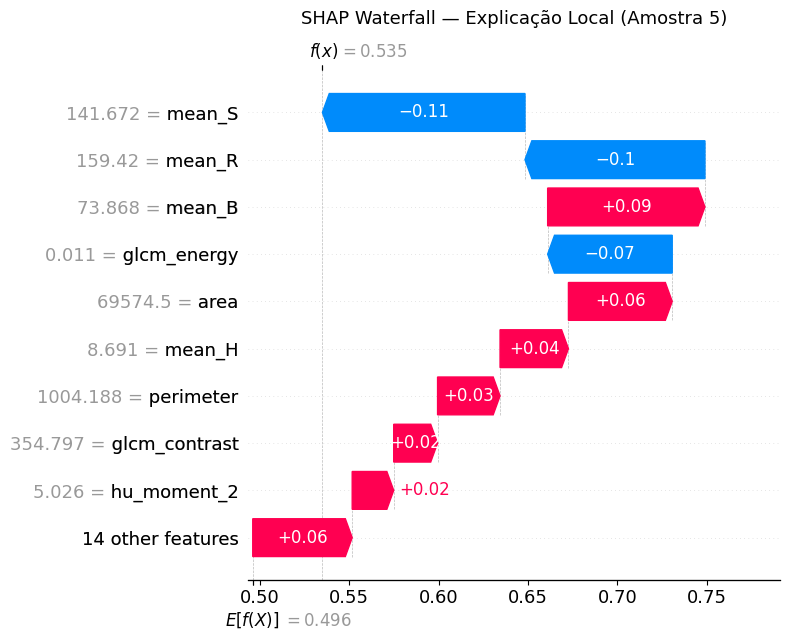

In [16]:
# Carrega o Random Forest GrabCut salvo pelo notebook 03
rf_model  = joblib.load("../outputs/models/rf_grabcut.pkl")
scaler    = joblib.load("../outputs/models/scaler_grabcut.pkl")
colunas   = joblib.load("../outputs/models/features_grabcut.pkl")

X_real = pd.read_csv("../outputs/X_grabcut.csv")
if "Unnamed: 0" in X_real.columns:
    X_real = X_real.drop(columns=["Unnamed: 0"])

# Usa uma amostra para eficiência computacional do SHAP
SHAP_SAMPLE = min(200, len(X_real))
X_shap = X_real.sample(n=SHAP_SAMPLE, random_state=42).reset_index(drop=True)

print(f"Calculando SHAP values sobre {SHAP_SAMPLE} amostras...")
explainer   = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)

# Normalize to always get a 2D array (n_samples, n_features) for class 1
if isinstance(shap_values, list):
    # Old SHAP: list of [class_0_array, class_1_array]
    sv2d = shap_values[1]
elif shap_values.ndim == 3:
    # New SHAP: single array (n_samples, n_features, n_classes)
    sv2d = shap_values[:, :, 1]
else:
    sv2d = shap_values  # already 2D

base_val = explainer.expected_value
if isinstance(base_val, (list, np.ndarray)):
    base_val = float(base_val[1])
else:
    base_val = float(base_val)

print(f"sv2d shape: {sv2d.shape}, base_val: {base_val:.4f}")

# ── Summary plot ────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(sv2d, X_shap, show=False)
plt.title("SHAP — Impacto Global das Features (Classe: Rotten)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_summary.png", dpi=200, bbox_inches="tight")
plt.show()

# ── Waterfall plot (single sample) ──────────────────────────────────────────
exp = shap.Explanation(
    values=sv2d[5],                  # 1D: (n_features,)
    base_values=base_val,            # scalar
    data=X_shap.iloc[5].values,      # 1D: (n_features,)
    feature_names=list(X_shap.columns),
)

print(f"Explanation values shape: {exp.values.shape}")  # should be (n_features,)

plt.figure(figsize=(9, 7))
shap.plots.waterfall(exp, show=False)
plt.title("SHAP Waterfall — Explicação Local (Amostra 5)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("../outputs/figures/shap_waterfall.png", dpi=200, bbox_inches="tight")
plt.show()


## Conclusão do Bônus

O **Transfer Learning com MobileNetV2** geralmente supera o pipeline clássico em acurácia
porque usa representações de alto nível aprendidas em 1.4M imagens (ImageNet), sem depender
de features manuais que podem falhar em casos limítrofes.

A **análise SHAP** revela que o Random Forest clássico depende principalmente de features de **cor**
(saturação e matiz) para distinguir frutas frescas de podres — o que faz sentido biologicamente,
pois a deterioração causa perda de pigmentação e escurecimento da casca.

A combinação de ambos — pipeline clássico interpretável + CNN como benchmark — é o padrão
recomendado em sistemas industriais onde **auditabilidade** e **eficiência** são igualmente
importantes.
